# Synthetic Control - Reducing Smoking In California

In this notebook we practice the synthetic control method by reproducing the results from the Abadie, Diamond, Hainmueller (2007) paper. In this paper the authors studied the effect of proposition 99, a large tobacco control programme implemented in California, on the number of packets of cigarettes consumed per capita. Before the synthetic control method was introduced, a researcher would have run a timeseries or a comparative study. Timeseries studies are fine when the short term effect is large, but as time goes on it becomes difficult to seperate noise/further shocks from the effect of the treatment. Comparative studies whilst very popular have the drawback that comparisons are selected based on subjective perceptions of similarity with the treated, furthermore, when the units of interest are large aggregates (e.g. countries, states, regions etc...) it is likely that there is not a single unit that is comparable to the treated. Synthetic control was introduced in response to these issues. Further details are below, at a high level, synthetic control builds a counterfactual of the treated by selecting the weighted average of units in the donor pool that minimises some distance metric between the covariates that we think are important. For example, when the UK left the EU, to measure the effect on the economy we could build a *synthetic UK* that is some linear combination of other similar Europena countries such that the weighted sum across some indicators we think are important, like unemployment, inflation and per capita GDP is as similar as possible to the UK's own figures.

This notebook is structured as follows: we write down the synthetic control estimator mathematically explaining how it works, then we load the data and run both the naive estimator and the synthetic control estimator, we also write the code to implement synthetic control explaining the functions implemented and how they work, finally we run some diagnostic tests to check the robustness of our estimate before closing out with a discussion of the bias and why OLS is not suitable for the job

## Synthetic Control Estimator

Here we describe the set up and estimation steps in synthetic control. Firstly, we have $J+1$ units, $1, 2, ..., J+1$ assume that unit $1$ is our unit of interest - the treated unit. For each unit $j$ and time $t$ we observe the outcome of interested $Y_{jt}. Every time period $t$ up to $T_{0}$ is the preintervention period, and all time periods thereafter are the post intervention period. Each unit, $j$, is asscoiated with a $K\text{x}1$ covariate vector $X_{j} = [x_{j1}, ..., x_{jk}]$. The $K\text{x}J$ matrix $X_{0} = [X_{2},...,X_{J+1}]$ collects these values for the untreated units. For each unit $j$ we define $Y^{N}_{jt}$ to be the potential response without intervention and $Y^{I}_{jt}$ to be the potential response under intervention - these are the potential outcomes in Rubin's framework. Given this the effect we are interested in is

$$
\tau_{1t} = Y^{I}_{1t} - Y^{N}_{1t}
$$

A couple of things to note here. First, unit $1$ is exposed to the treatment therefore, $Y^{I}_{1t} = Y_{1t}$ and we only need to estimate the outcome under no treatment for $t>T_{0}$. Furthermore, notice how the equation allows for varying effects with $t$, this is important because interventions may not effect the metric of interest instantly, or their effect may dissipate i.e. the effect is non-linear over time.

Now we have our set up we cant talk about our estimator. The synthetic control estimator of $Y^{N}_{1t}$ is:

$$
\hat{Y}^{N}_{1t} = \sum_{j=2}^{J+1}w_{j}Y_{jt}
$$

$$
\tau_{1t} = Y^{I}_{1t} - \hat{Y}^{N}_{1t} 
$$

Now we need to estimate the $J\text{x}1$ weight vector $W=(w_{2},...,w_{j+1})$. We do this by selecting the $W^{*}$ that minimises:

$$
||X_{1} - X_{0}W||_{v}
$$

Subject to the restrictions, 

$$
\sum_{j=2}^{j}w_{j} = 1
$$ 
$$
\forall j \space w_{j} \ge 0
$$

This is a weighted norm, weighted by the $K\text{x}1$ vector $V$, therefore it is equal to

$$
(\sum_{i=1}^{k}v_{i}(X_{i1} - w_{2}X_{i2} - ... - w_{j+1}X_{ij+1})^{2})^{\frac{1}{2}}
$$

$V$ reflects the relative importance each of the predictors in $X$. The estimated treatment effect is therefor,

$$
\tau_{1t} = Y_{1t} - \sum_{j=2}^{j+1}w^{*}_{j}Y_{jt}
$$

All that remains is the choice of $V$. We could select the inverse of the variance, or we could select $V$ such that the pre-treatment prediction error is minimised. Below we will experiment with different choices.

In [49]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fmin_slsqp
from functools import partial
from get_data import load_smoking

## Load Data

The dataset contains the number of cigarette packets sold per capita for a given state in a given year. Alongside cigarette sales the dataset also contains some other covariates the authors of the original paper suggested are causal of the amount of cigarette sales along with two columns to identify California and the pre/post-intervention periods

In [50]:
df = load_smoking()
df.head()

,state,year,cigsale,lnincome,beer,age15to24,retprice,california,after_treatment
0,Alabama,1970,89.800003,NaN,NaN,0.178862,39.599998,False,False
1,Alabama,1971,95.400002,NaN,NaN,0.179928,42.700001,False,False
2,Alabama,1972,101.099998,9.498476,NaN,0.180994,42.299999,False,False
3,Alabama,1973,102.900002,9.550107,NaN,0.182060,42.099998,False,False
4,Alabama,1974,108.199997,9.537163,NaN,0.183126,43.099998,False,False


## Naive Comparatison

The naive comparison is the comparison between the smoking rates in california versus the rest of the USA. However, this is not a good way to accurately retrieve the effect of the policy because whole of the USA may not be a good counterfactual for what would have happend in California had prop 99 not been passed. As we can see in the chart below the preintervention trends are very different, smoking rates in California began to fall earlier than in the rest of the USA and at a greater rate. The result is an overestimate of the impact of the policy. 

Also note that this naive comparison is a synthetic control estimator where each unit in the donor pool is given an equal weight - why not use a data driven way to estimate the weights?

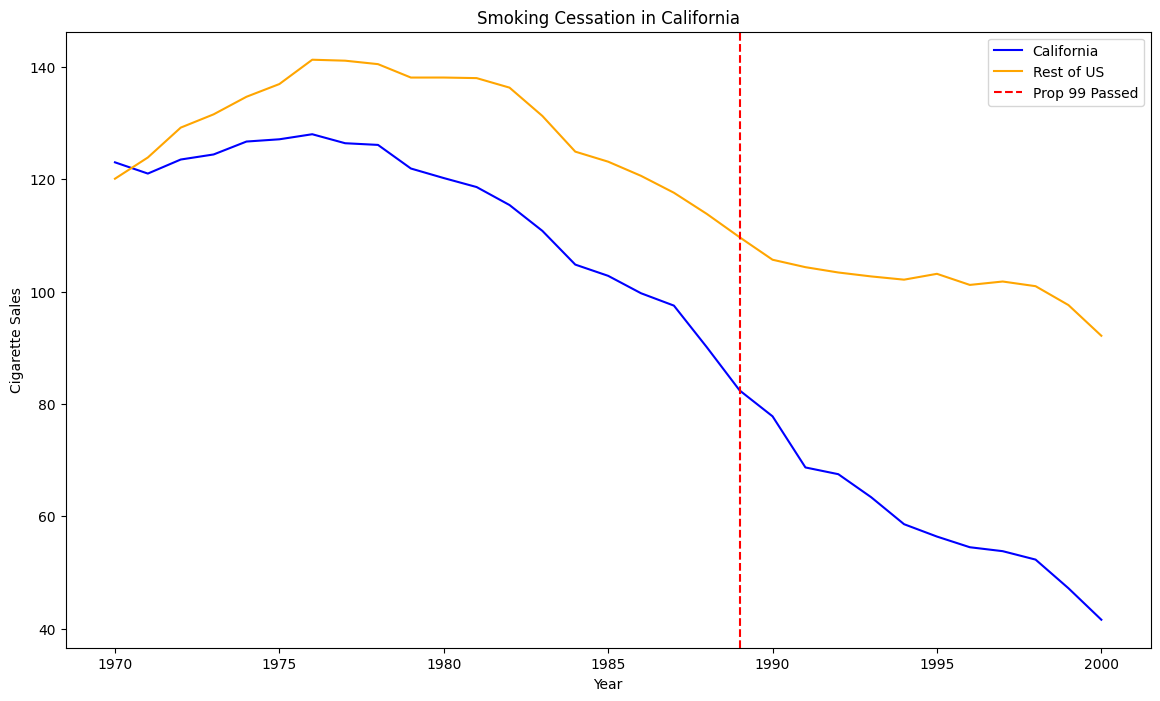

In [51]:
california = df[df["state"] == "California"]
rest_of_us = df[df["state"] != "California"]

fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(california["year"], california["cigsale"], label="California", color="blue")
ax.plot(rest_of_us.groupby("year")["cigsale"].mean(), label="Rest of US", color="orange")
ax.axvline(x=1989, color="red", linestyle="--", label="Prop 99 Passed")
ax.set_xlabel("Year")
ax.set_ylabel("Cigarette Sales")
ax.set_title("Smoking Cessation in California")
ax.legend()
plt.show()


In [52]:
effect_by_2000_naive = california[california["year"] == 2000]["cigsale"].values[0] - rest_of_us[rest_of_us["year"] == 2000]["cigsale"].mean()
print(f"Naive estimate of the effect of Prop 99 on cigarette sales in California by 2000: {effect_by_2000_naive:.2f} packs per capita")

Naive estimate of the effect of Prop 99 on cigarette sales in California by 2000: -50.53 packs per capita


## Synthetic Control Implementation

Below are two functions which together implement the synthetic control estimator. First we have the `loss_function` this returns the value of 

$$
||X_{1} - X_{0}W||_{v}
$$

then we have the function `get_w`. This function finds the $W$ that minimise the loss whilst meeting the constraints. 

The next step is to format our data correctly. We want to learn the weights for each country such that the difference in the preintervention values of the outcome are minimised. This requires a matrix where the donor pool are the columns and the year-covariate pairs the columns. **note** In the original paper the authors proposed learning the weights by minimising the difference between a set of covariates that caused the outcome, however, more recent implementations usually use the preintervention periods to find the weights. Here we use the preintervention periods and cigarette retail price to learn the weights. Also note our choice of $V$, we use the identity matrix which enforces that each covariate we use is given equal weight in the loss function.

This implementation only uses 5 units in the donor pool to create synthetic california and New Mexico accounts for 45% of the weighting (this is a sparse solution which is one of the benefits of synthetic control).

We plot the pre and post-intervention trends for California and synthetic california, note how much more similar the preintervention trend is between the two than California vs the USA. By the year 2000, cigarette sales are down by 25 packs per capita per year in California vs synthetic california which is only half the estimated impact of the naive estimate confirming that this method overestimated the impact of the policy.

In [53]:
def loss_function(W, V, X1, X0) -> float:
    """
    Loss function for the synthetic control method.
    """
    return np.sqrt((X1 - X0 @ W).T @ V @ (X1 - X0 @ W))

def get_w(X1, X0, V) -> np.ndarray:
    """
    Get the weights for the synthetic control method.
    """
    n = X0.shape[1]
    w0 = np.ones(n) / n
    result = fmin_slsqp(
        partial(loss_function, X1=X1, X0=X0, V=V), 
        w0, 
        f_eqcons=lambda W: np.sum(W) - 1,
        bounds= [(0, 1) for _ in range(n)],
        disp=False,
    )
    return result

In [54]:
features = ["cigsale", "retprice"]
inverted = df[~df['after_treatment']].pivot(index="state", columns="year")[features].T
inverted.head()


state            Alabama    Arkansas  California    Colorado  Connecticut  \
        year                                                                
cigsale 1970   89.800003  100.300003  123.000000  124.800003   120.000000   
        1971   95.400002  104.099998  121.000000  125.500000   117.599998   
        1972  101.099998  103.900002  123.500000  134.300003   110.800003   
        1973  102.900002  108.000000  124.400002  137.899994   109.300003   
        1974  108.199997  109.699997  126.699997  132.800003   112.400002   

state           Delaware     Georgia       Idaho    Illinois     Indiana  ...  \
        year                                                              ...   
cigsale 1970  155.000000  109.900002  102.400002  124.800003  134.600006  ...   
        1971  161.100006  115.699997  108.500000  125.599998  139.300003  ...   
        1972  156.300003  117.000000  126.099998  126.599998  149.199997  ...   
        1973  154.699997  119.800003  121.800003  124.400002  156.000000  ...   
        1974  151.300003  123.699997  125.599998  131.899994  159.600006  ...   

state         South Carolina  South Dakota   Tennessee       Texas       Utah  \
        year                                                                    
cigsale 1970      103.599998     92.699997   99.800003  106.400002  65.500000   
        1971      115.000000     96.699997  106.300003  108.900002  67.699997   
        1972      118.699997    103.000000  111.500000  108.599998  71.300003   
        1973      125.500000    103.500000  109.699997  110.400002  72.699997   
        1974      129.699997    108.400002  114.800003  114.699997  75.599998   

state            Vermont    Virginia  West Virginia   Wisconsin     Wyoming  
        year                                                                 
cigsale 1970  122.599998  124.300003     114.500000  106.400002  132.199997  
        1971  124.400002  128.399994     111.500000  105.400002  131.699997  
        1972  138.000000  137.000000     117.500000  108.800003  140.000000  
        1973  146.800003  143.100006     116.599998  109.500000  141.199997  
        1974  151.800003  149.600006     119.900002  111.800003  145.800003  

[5 rows x 39 columns]

In [55]:
states = inverted.columns.drop("California")

In [56]:
X1 = inverted.loc[:, "California"].values
X0 = inverted.drop(columns="California").values

In [57]:
weights = get_w(X1, X0, V=np.eye(X0.shape[0])) # V is equal weights for each feature
np.round(weights, 4)


array([0.    , 0.    , 0.    , 0.0852, 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.113 , 0.105 , 0.4566, 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.2401, 0.    , 0.    , 0.    , 0.    , 0.    ])

C:\Users\caine\AppData\Local\Temp\ipykernel_17944\4102325605.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(weights_dict.keys(), rotation=90)


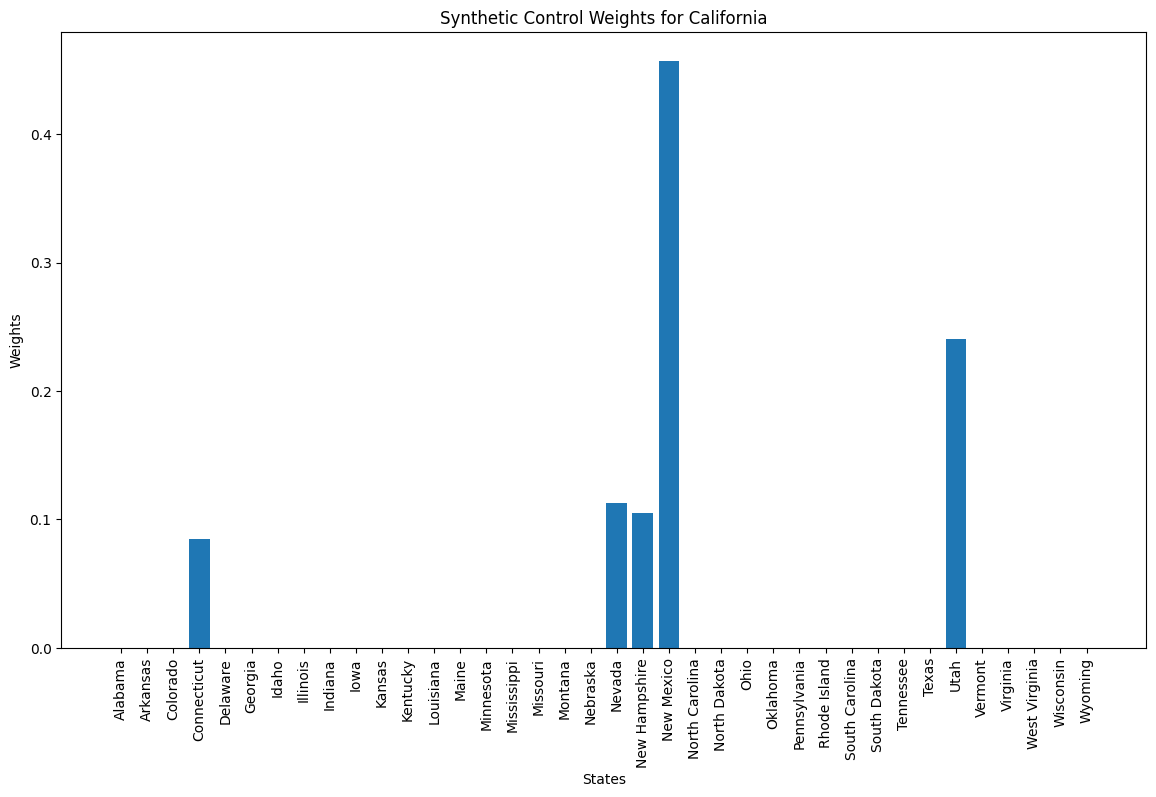

In [58]:
weights_dict = {state: weight for state, weight in zip(states, np.round(weights, 4))}

fig, ax = plt.subplots(figsize=(14, 8))
ax.bar(weights_dict.keys(), weights_dict.values())
ax.set_xlabel("States")
ax.set_ylabel("Weights")
ax.set_title("Synthetic Control Weights for California")
ax.set_xticklabels(weights_dict.keys(), rotation=90)
plt.show()

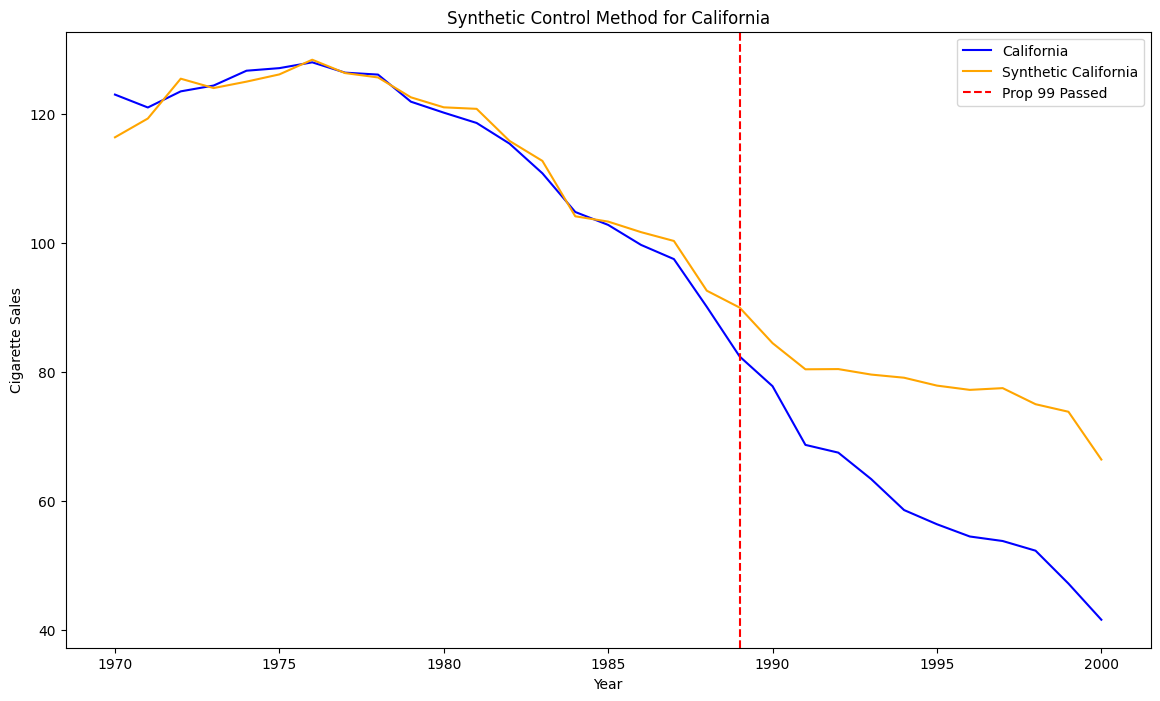

In [59]:
synthetic_california = weights @ df[df["state"] != "California"].pivot(columns="year", index="state")["cigsale"].values

fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(california["year"], california["cigsale"], label="California", color="blue")
ax.plot(california["year"], synthetic_california, label="Synthetic California", color="orange")
ax.axvline(x=1989, color="red", linestyle="--", label="Prop 99 Passed")
ax.set_xlabel("Year")
ax.set_ylabel("Cigarette Sales")
ax.set_title("Synthetic Control Method for California")
ax.legend()

In [60]:
synthetic_control_effect_estimate_2000 = california[california["year"] == 2000]["cigsale"].values[0] - synthetic_california[-1]
print(f"Estimated effect of Prop 99 on cigarette sales in California by 2000 using the synthetic control method: {synthetic_control_effect_estimate_2000:.2f} packs per capita")

Estimated effect of Prop 99 on cigarette sales in California by 2000 using the synthetic control method: -24.83 packs per capita


## Diagnostics

Below we run two diagnostics tests to evaluate the strength of our findings. Be aware that there is more we could do to evaluate our analysis - if you're interested see sec tion 7 of Abadie (2021).

### Fisher Exact Test

Our first diagnostic is the fisher exact test. This cycles through all of the units in the donor pool and fits the synthetic control estimator. Then we calculate the gap at each time period between the actual value and the synthetic control. We plot all of these series and this will gve us a sense of how extreme the value is the California. The idea is that all of the donor pool are untreated, if we see many units with a gap between themselves and their synthetic control that is greater than the one we see for California then this is an indication that the observation could be a statistical fluke rather than the impact of the policy. Furthermore, we can calculate the the number of units with a value more extreme than California's to get a P-value for the hypothesis that there was no effect of the policy.

We find that the one sided p-value for the null that the policy had no impact on California is 0.03% therefore we reject the null.

In [61]:
def fit_synthetic_control(data: pd.DataFrame, state: int) -> list[str, np.ndarray]:
    """
    Fit a synthetic control model for a given state.
    """
    inverted = data[~data['after_treatment']].pivot(index="state", columns="year")[features].T
    inverted.columns.drop(state)

    X1 = inverted.loc[:, state].values
    X0 = inverted.drop(columns=state).values

    weights = get_w(X1, X0, V=np.eye(X0.shape[0]))
    synthetic_state = weights @ data[data["state"] != state].pivot(columns="year", index="state")["cigsale"].values

    gap = data[data["state"] == state].pivot(columns="year", index="state")["cigsale"].values - synthetic_state

    return [state, gap[0]]

In [62]:
from joblib import Parallel, delayed

results = Parallel(n_jobs=-1)(delayed(fit_synthetic_control)(df, state) for state in df['state'].unique())


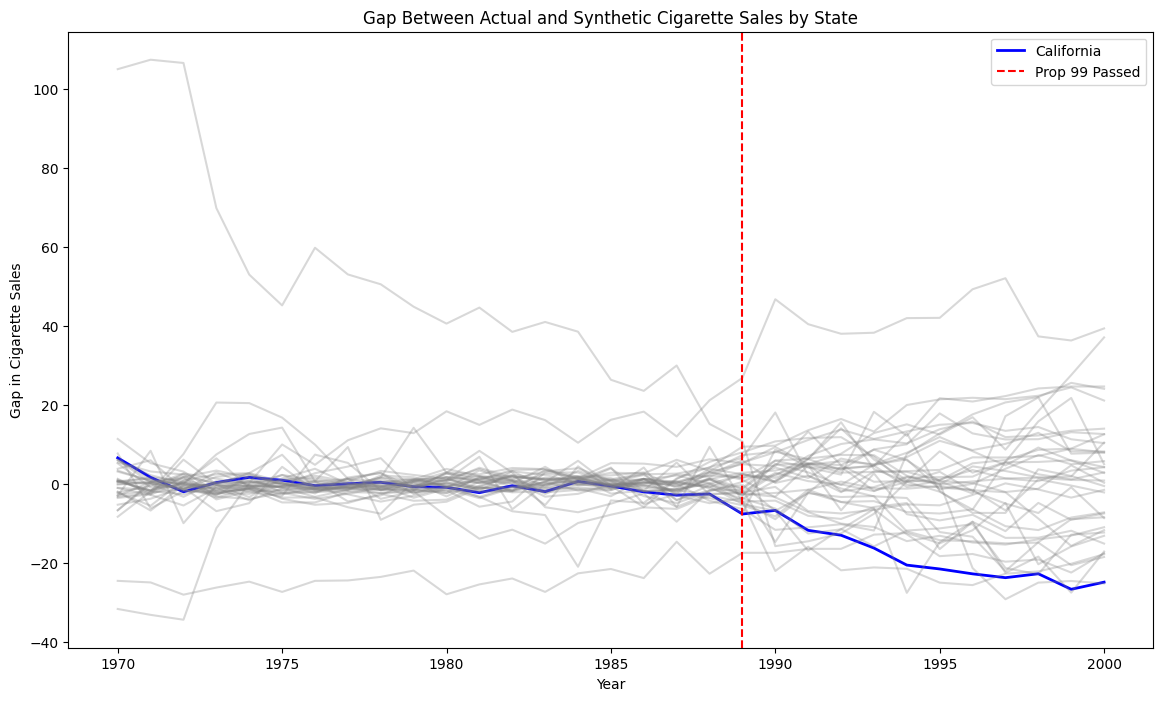

In [63]:
fig, ax = plt.subplots(figsize=(14, 8))
for state, gap in results:
    if state == "California":
        ax.plot(df[df["state"] == state]["year"], gap, label=state, color="blue", linewidth=2)
    else:
        ax.plot(df[df["state"] == state]["year"], gap,  color="gray", alpha=0.3)

ax.axvline(x=1989, color="red", linestyle="--", label="Prop 99 Passed")
ax.set_title("Gap Between Actual and Synthetic Cigarette Sales by State")
ax.set_xlabel("Year")
ax.set_ylabel("Gap in Cigarette Sales")
ax.legend()
plt.show()

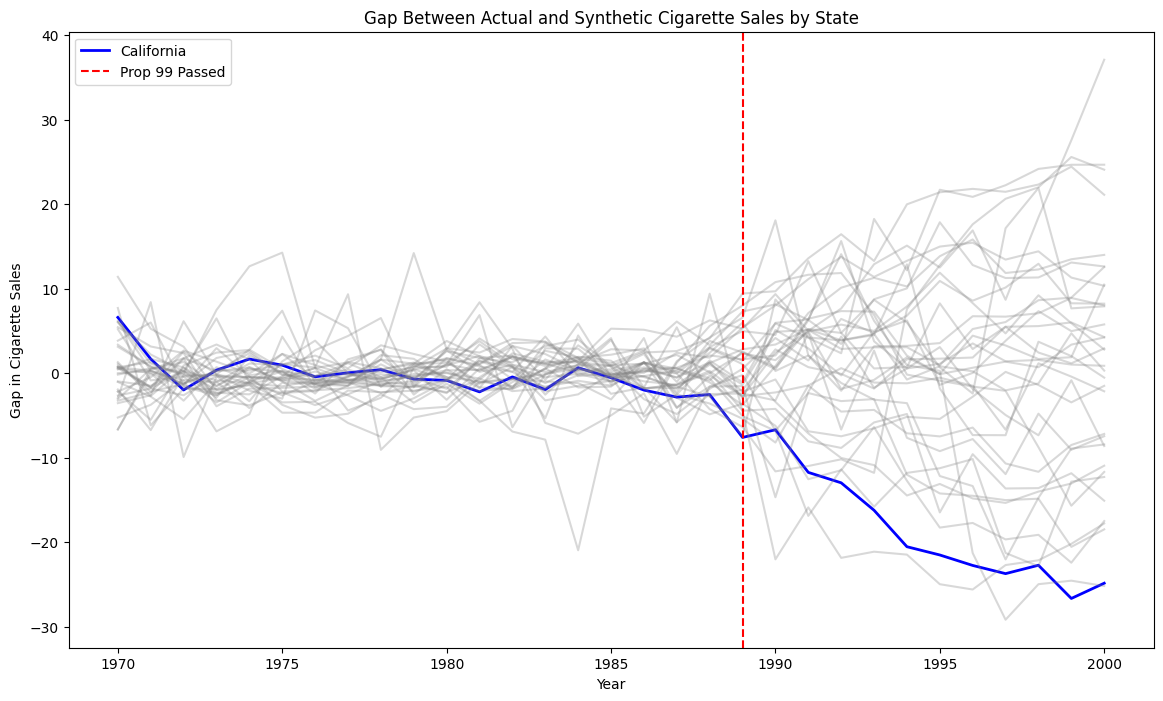

In [64]:
fig, ax = plt.subplots(figsize=(14, 8))
for state, gap in results:

    if state == "California":
        ax.plot(df[df["state"] == state]["year"], gap, label=state, color="blue", linewidth=2)
    else:
        # Skip states with large pre intervention MSE - they are outlier who had no good synthetic control match
        if ((gap[:19]**2).mean()) < 80:
            ax.plot(df[df["state"] == state]["year"], gap, color="gray", alpha=0.3)

ax.axvline(x=1989, color="red", linestyle="--", label="Prop 99 Passed")
ax.set_title("Gap Between Actual and Synthetic Cigarette Sales by State")
ax.set_xlabel("Year")
ax.set_ylabel("Gap in Cigarette Sales")
ax.legend()
plt.show()

In [65]:
trimmed_results = [r for r in results if ((r[1][:19]**2).mean()) < 80]
trimmed_effects = np.array([r[1][-1] for r in trimmed_results if r[0] != "California"])
one_sided_p_value = np.sum(trimmed_effects < synthetic_control_effect_estimate_2000) / len(trimmed_effects)

print(f"One-sided p-value for the effect of Prop 99 on cigarette sales in California: {one_sided_p_value:.4f}")

One-sided p-value for the effect of Prop 99 on cigarette sales in California: 0.0294


## Backdating

Next we apply backdating. The idea here is that we artifically set the intervention to a point earlier in time. Now the synthetic control method can only use these periods to learn the weights. What we hope to see is that synthetic control learns similar weights and that post intervention (post artificial intervention that is) we see that the unit of interest and the synthetic unit still track each other closely until the real intervention date.

If we set the preintervention period to 1980 we do get different weights. Noticeably New Mexico drops out! However we do see that Conneticut, Nevada and Utah are still represented. Despite the different weights, the line plot of California vs synthetic California is encouraging. We see that even after the artificial intervention the two units still track each other relatively well - at least up until about 1987 - and we see that the gap does widen dramatically after the true intervention. Finally, the estimate of the effect by the year 2000 is in the same ball park.

In [66]:
inverted = df[df['year'] <= 1980].pivot(index="state", columns="year")[features].T

X1 = inverted.loc[:, "California"].values
X0 = inverted.drop(columns="California").values

weights = get_w(X1, X0, V=np.eye(X0.shape[0]))
np.round(weights, 4)

array([0.    , 0.    , 0.1339, 0.2755, 0.0015, 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.2328, 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.2851, 0.    , 0.    , 0.0712, 0.    , 0.    ])

C:\Users\caine\AppData\Local\Temp\ipykernel_17944\4102325605.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(weights_dict.keys(), rotation=90)


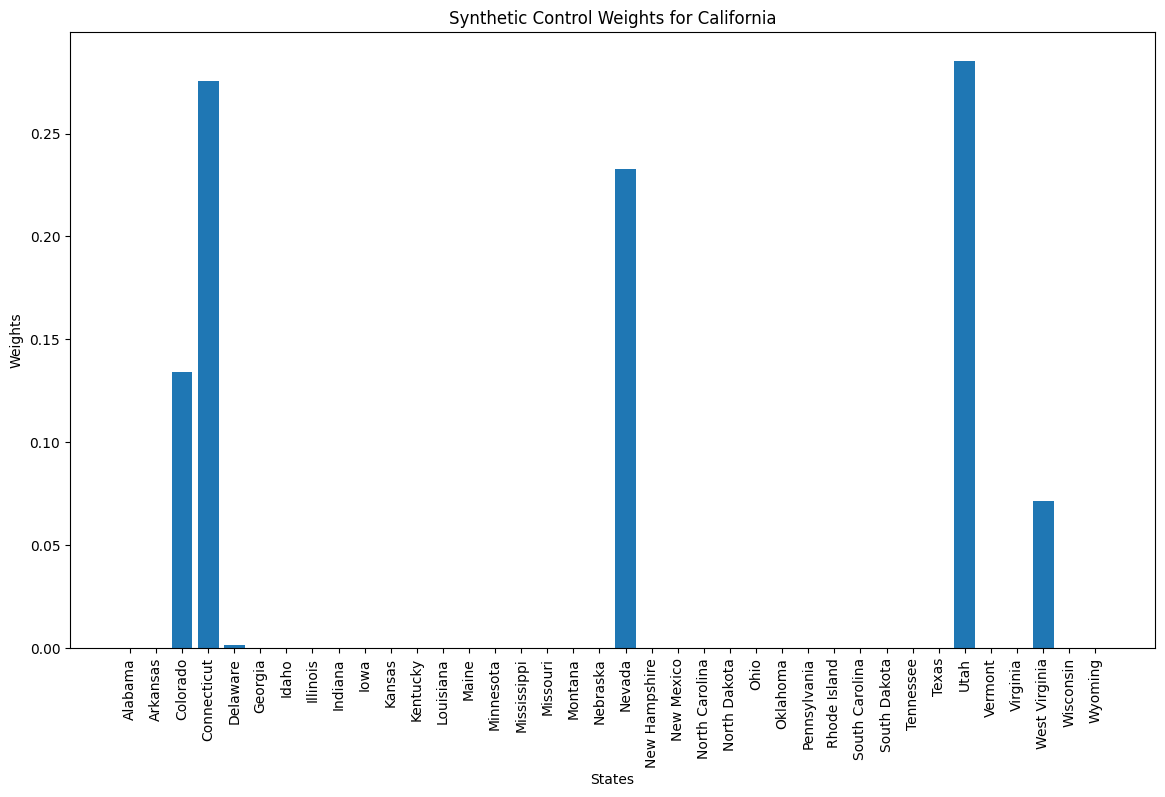

In [67]:
weights_dict = {state: weight for state, weight in zip(states, np.round(weights, 4))}

fig, ax = plt.subplots(figsize=(14, 8))
ax.bar(weights_dict.keys(), weights_dict.values())
ax.set_xlabel("States")
ax.set_ylabel("Weights")
ax.set_title("Synthetic Control Weights for California")
ax.set_xticklabels(weights_dict.keys(), rotation=90)
plt.show()

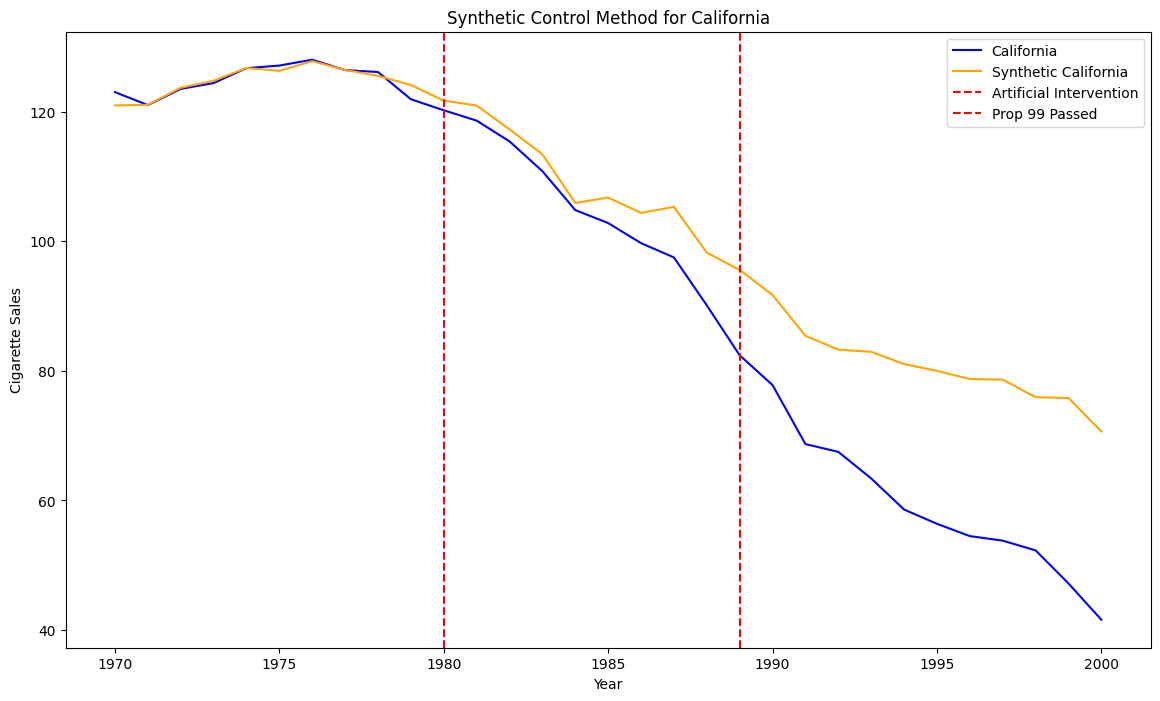

In [68]:
synthetic_california = weights @ df[df["state"] != "California"].pivot(columns="year", index="state")["cigsale"].values

fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(california["year"], california["cigsale"], label="California", color="blue")
ax.plot(california["year"], synthetic_california, label="Synthetic California", color="orange")
ax.axvline(x=1980, color="red", linestyle="--", label="Artificial Intervention")
ax.axvline(x=1989, color="red", linestyle="--", label="Prop 99 Passed")
ax.set_xlabel("Year")
ax.set_ylabel("Cigarette Sales")
ax.set_title("Synthetic Control Method for California")
ax.legend()

In [69]:
synthetic_control_effect_estimate_2000 = california[california["year"] == 2000]["cigsale"].values[0] - synthetic_california[-1]
print(f"Estimated effect when intervention period is backdated to 1980 on cigarette sales in California by 2000 using the synthetic control method: {synthetic_control_effect_estimate_2000:.2f} packs per capita")

Estimated effect when intervention period is backdated to 1980 on cigarette sales in California by 2000 using the synthetic control method: -29.05 packs per capita


## Bias

Here we analyse the bias of the synthetic control estimator under the assumption that we have a linear model (for a fuller treatment see Abadia (2021)). We assume the following linear model for the outcome 

$$
Y^{N}_{jt} = \delta_{t} + \theta_{t}Z_{j} + \lambda_{t}U_{j} + \epsilon_{t}
$$

Here $\delta_{t}$ is the time trend, $Z_{j},U_{j}$ are the vectors of observed and unobserved covariates respectively for unit $j$ with $\theta_{t}, \lambda_{t}$ being vectors of coefficients for the covariates and $\epsilon_{t}$ is a zero mean shock variable. The outcome $Y^{N}_{jt}$ is the value of the outcome for unit $j$ at time $t$ under the situation where there is no intervention.

The bias of our synthetic control estimator given this is the true model is the ratio between the $\epsilon_{t}$ and the number of time periods $T_{0}$ in the pre-intervention period. Why? Well consider that if we create a synthetic control estimator that well matches the unit of interest in the preintervention period then there are two possibilities

1. The effect of $U$ relative to $Z$ is very small
2. We got lucky with a shock $\epsilon_{t}$

However, we assume that $\epsilon_{t}$ has mean zero, so if we have many time periods it would be very unlikely that we got lukcy with the preintervention tracking each other closely.

Therefore we have,

$$
bias =  C \times \frac{\epsilon_{t}}{T_{0}} 
$$

when the assumption of a linear model is correct **and** our synthetic control estimator closely matches the unit of interest in the preintervention period.

# Why Not OLS?

Finally, after all of this you might be wondering, "why don't we just use OLS?". And you would be right to ask this question. After all the two methods are very similar. However, the key difference are the constraints we set of the weights that the synthetic control estimator can learn. Remember all weights must be non-negative and they must sum to one. The key result is that the synthetic control unit is an interpolation of the units in the donor pool, that is the solution lies within the bounds of the data. Linear regression allows for negative weights, this means the solution can be an extrapolation, it lies outside of the data. Extrapolation can be dangerous and hard to interpret. 

Furthermore, the synthetic control solution guarantees a sparse solution (most of the units in the donor pool will have a weight of zero). OLS cannot guarantee this althoug using the LASSO we can. A sparse solution is desirable when we use synthetic control for two reasons. Firstly, it is easier to interpret and reason about. Secondly, it prevents overfitting. Remember when we are applying synthetic control we have a set of units with an associated outcome overtime. Often it will be the case that we have more units than time periods and therefore can always fit the data perfectly. For example, in this case study we had 31 time periods but 39 states.

## Bibliography

Abadie, A. (2021). Using synthetic controls: Feasibility, data requirements, and methodological aspects. *Journal of Economic Literature*, 59(2), 391–425.

Abadie, A., Diamond, A., & Hainmueller, J. (2007). *Synthetic control methods for comparative case studies: Estimating the effect of California's Tobacco Control Program* (NBER Technical Working Paper No. 335). National Bureau of Economic Research.

Cunningham, S. (2021). *Causal inference: The mixtape*. Yale University Press.

Fisher, R. A. (1935). *The design of experiments*. Oliver & Boyd.